requirements

In [15]:
!pip install great-tables  #si non installé

In [16]:
import pandas as pd

In [17]:
import fonctions
import importlib
importlib.reload(fonctions)

<module 'fonctions' from '/home/onyxia/work/dm_pds/fonctions.py'>

Import des données 

In [18]:
df = pd.read_csv(
 'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb'
)

/tmp/ipykernel_33906/3633677116.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Import des fonctions du fichier fonctions.py nécessaires au DM 

In [19]:
from fonctions import * 

la tete des données ça ressemble à quoi

In [20]:
df.head(5)

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
0,01,Ain,1,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3
1,01,Ain,2,L'Abergement-de-Varey,Nathalie,ARTHAUD,2
2,01,Ain,4,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38
3,01,Ain,5,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8
4,01,Ain,6,Ambléon,Nathalie,ARTHAUD,0


In [21]:
df.dtypes

code_departement       object
libelle_departement    object
code_commune            int64
libelle_commune        object
prenom                 object
nom                    object
voix                    int64
dtype: object

In [22]:
df.sample

<bound method NDFrame.sample of        code_departement              libelle_departement  code_commune  \
0                    01                              Ain             1   
1                    01                              Ain             2   
2                    01                              Ain             4   
3                    01                              Ain             5   
4                    01                              Ain             6   
...                 ...                              ...           ...   
528670      fr_etranger  Français établis hors de France           229   
528671      fr_etranger  Français établis hors de France           231   
528672      fr_etranger  Français établis hors de France           233   
528673      fr_etranger  Français établis hors de France           234   
528674      fr_etranger  Français établis hors de France           235   

                libelle_commune    prenom      nom  voix  
0       L'Abergement

**Question 1**

In [23]:
#vérification du format : pour que "01" reste "01" et ne devienne pas "1"
df["code_departement"] = df["code_departement"].astype(str).str.zfill(2)
df["code_commune"] = df["code_commune"].astype(str).str.zfill(3)

df["code_commune"] = df["code_departement"] + df["code_commune"]

df["candidat"] = df["prenom"].fillna("") + " " + df["nom"].fillna("")

vérification de la manip

In [24]:
df.dtypes

code_departement       object
libelle_departement    object
code_commune           object
libelle_commune        object
prenom                 object
nom                    object
voix                    int64
candidat               object
dtype: object

In [25]:
df.head(2)

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix,candidat
0,01,Ain,01001,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3,Nathalie ARTHAUD
1,01,Ain,01002,L'Abergement-de-Varey,Nathalie,ARTHAUD,2,Nathalie ARTHAUD


vérifions si on a bien gardé les bulletins abstentions, blancs ou nuls

In [26]:
df["candidat"].str.contains("BLANC|NUL|ABSTENTION", case=False, na=False).any()

np.True_

Question 2 

In [27]:
fonctions.compter_candidats(df)

"En 2022, il y avait 15 candidats à l'élection présidentielle."


Question 3 


résultat en basique 


In [28]:
fonctions.scores_nationaux_2(df)


,candidat,votes,score
1,Emmanuel MACRON,9783058,27.845822
5,Marine LE PEN,8133828,23.151568
4,Jean-Luc MÉLENCHON,7712520,21.952386
11,Éric ZEMMOUR,2485226,7.073776
9,Valérie PÉCRESSE,1679001,4.778993
10,Yannick JADOT,1627853,4.633409
3,Jean LASSALLE,1101387,3.134912
2,Fabien ROUSSEL,802422,2.283959
7,Nicolas DUPONT-AIGNAN,725176,2.064091
0,Anne HIDALGO,616478,1.754701


en joli tableau : 

In [29]:
from great_tables import GT

GT(fonctions.scores_nationaux_2(df)).tab_header(
    title="Résultats Présidentielles 2022 (T1)"
)

GT(_tbl_data=                 candidat    votes      score
1         Emmanuel MACRON  9783058  27.845822
5           Marine LE PEN  8133828  23.151568
4      Jean-Luc MÉLENCHON  7712520  21.952386
11           Éric ZEMMOUR  2485226   7.073776
9        Valérie PÉCRESSE  1679001   4.778993
10          Yannick JADOT  1627853   4.633409
3           Jean LASSALLE  1101387   3.134912
2          Fabien ROUSSEL   802422   2.283959
7   Nicolas DUPONT-AIGNAN   725176   2.064091
0            Anne HIDALGO   616478   1.754701
8         Philippe POUTOU   268904   0.765390
6        Nathalie ARTHAUD   197094   0.560995, _body=<great_tables._gt_data.Body object at 0x7f437b5f4050>, _boxhead=Boxhead([ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label='candidat', column_align='left', column_width=None), ColInfo(var='votes', type=<ColInfoTypeEnum.default: 1>, column_label='votes', column_align='right', column_width=None), ColInfo(var='score', type=<ColInfoTypeEnum.default: 1>, column_label='score', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f437988bb60>, _spanners=Spanners([]), _heading=Heading(title='Résultats Présidentielles 2022 (T1)', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f437b5f4440>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f437b551450>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f437b5f4590>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8

Question 4

In [30]:
fonctions.scores_departements(df)

,code_departement,candidat,votes,score
1,01,Emmanuel MACRON,92206,27.687494
5,01,Marine LE PEN,86755,26.050675
4,01,Jean-Luc MÉLENCHON,57832,17.365715
11,01,Éric ZEMMOUR,27530,8.266671
9,01,Valérie PÉCRESSE,17572,5.276497
...,...,...,...,...
1291,fr_etranger,Nicolas DUPONT-AIGNAN,7074,1.417774
1287,fr_etranger,Jean LASSALLE,5964,1.195308
1286,fr_etranger,Fabien ROUSSEL,3266,0.654573
1292,fr_etranger,Philippe POUTOU,3145,0.630322


vérification avec le dep de l'Aude (11)

In [34]:
score_departements = fonctions.scores_departements(df)
df_11 = score_departements[score_departements["code_departement"] == "11"]
df_11

,code_departement,candidat,votes,score
125,11,Marine LE PEN,64027,30.140849
121,11,Emmanuel MACRON,43104,20.291301
124,11,Jean-Luc MÉLENCHON,42039,19.789950
131,11,Éric ZEMMOUR,18434,8.677845
123,11,Jean LASSALLE,12382,5.828853
129,11,Valérie PÉCRESSE,7350,3.460028
130,11,Yannick JADOT,6322,2.976095
120,11,Anne HIDALGO,6166,2.902658
122,11,Fabien ROUSSEL,5622,2.646569
127,11,Nicolas DUPONT-AIGNAN,4206,1.979984


Question 5 

In [36]:
import fonctions
import importlib
importlib.reload(fonctions)
score_departements = fonctions.comparaison_nationale(df)
df_11= score_departements[score_departements["code_departement"] == "11"]

df_11

,code_departement,candidat,votes_departement,score_departement,votes_national,score_national
120,11,Marine LE PEN,64027,30.140849,8133828,23.151568
121,11,Emmanuel MACRON,43104,20.291301,9783058,27.845822
122,11,Jean-Luc MÉLENCHON,42039,19.789950,7712520,21.952386
123,11,Éric ZEMMOUR,18434,8.677845,2485226,7.073776
124,11,Jean LASSALLE,12382,5.828853,1101387,3.134912
125,11,Valérie PÉCRESSE,7350,3.460028,1679001,4.778993
126,11,Yannick JADOT,6322,2.976095,1627853,4.633409
127,11,Anne HIDALGO,6166,2.902658,616478,1.754701
128,11,Fabien ROUSSEL,5622,2.646569,802422,2.283959
129,11,Nicolas DUPONT-AIGNAN,4206,1.979984,725176,2.064091


### Question 6
Création d'une variable surrepresentation qui compare, en relatif, les scores nationaux et départementaux

In [42]:
importlib.reload(fonctions)

score_departements = fonctions.calculer_surrepresentation(df)

score_departements.head(3)

,code_departement,candidat,votes_departement,score_departement,votes_national,score_national,surrepresentation
0,01,Emmanuel MACRON,92206,27.687494,9783058,27.845822,-0.568589
1,01,Marine LE PEN,86755,26.050675,8133828,23.151568,12.522294
2,01,Jean-Luc MÉLENCHON,57832,17.365715,7712520,21.952386,-20.893721


### Question 7


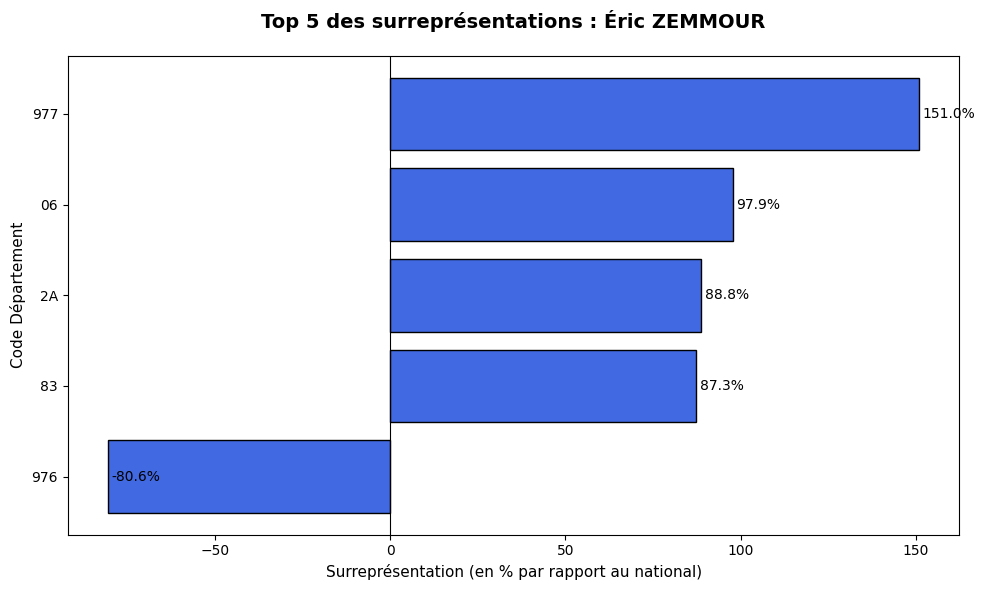

In [46]:
importlib.reload(fonctions)
fonctions.tracer_top_surrepresentations(score_departements, "Éric ZEMMOUR")

à executer si ça marche pas 

In [33]:
dir(fonctions)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'comparaison_departement',
 'comparaison_nationale',
 'compter_candidats',
 'pd',
 'scores_departements',
 'scores_nationaux_2']